# PART A — K-MEANS CLUSTERING (Clean Version)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

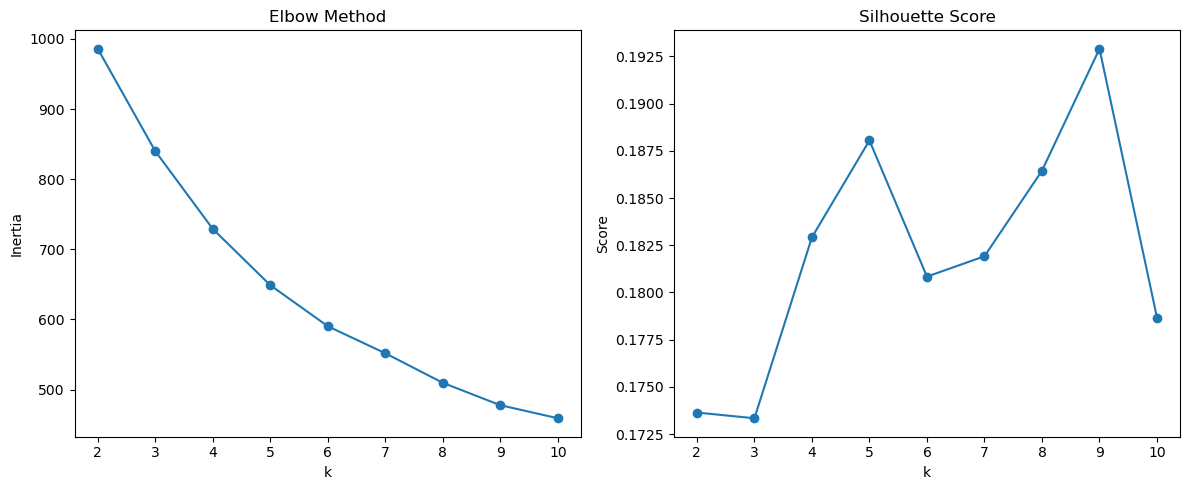

Optimal k: 9


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


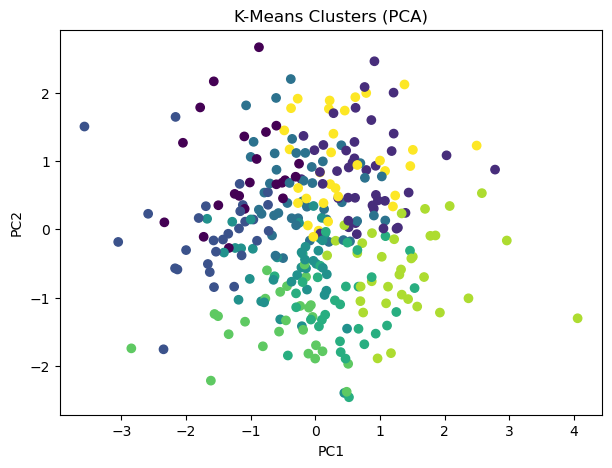

In [2]:
# ==========================================================
# PART A: K-MEANS CLUSTERING
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# -----------------------------
# Generate Customer Dataset
# -----------------------------

np.random.seed(42)
n_customers = 300

data = {
    'Annual_Income': np.random.normal(50000, 15000, n_customers),
    'Spending_Score': np.random.normal(50, 25, n_customers),
    'Age': np.random.normal(40, 12, n_customers),
    'Purchase_Frequency': np.random.normal(10, 5, n_customers)
}

df = pd.DataFrame(data)

# -----------------------------
# Scaling
# -----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# -----------------------------
# Elbow + Silhouette
# -----------------------------

k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow & Silhouette
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

# Optimal k
optimal_k = k_values[np.argmax(sil_scores)]
print("Optimal k:", optimal_k)

# -----------------------------
# PCA Visualization
# -----------------------------

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("K-Means Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# PART B — HIERARCHICAL CLUSTERING (Clean Version)

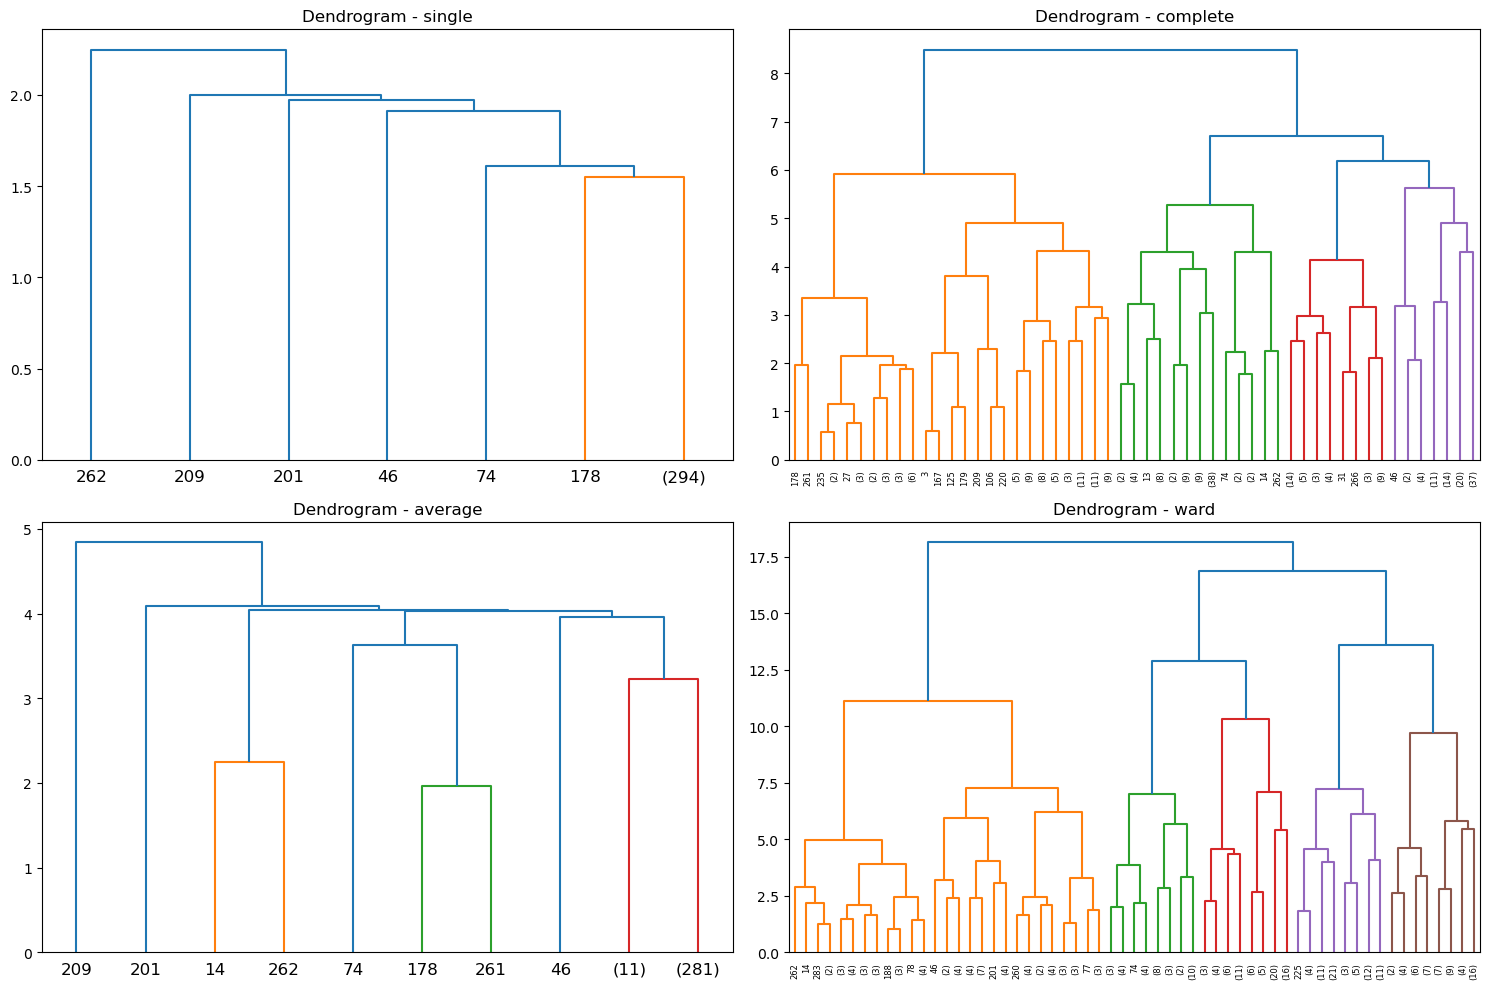

Single Silhouette Score: 0.055
Complete Silhouette Score: 0.12
Average Silhouette Score: 0.005
Ward Silhouette Score: 0.159


In [3]:
# ==========================================================
# PART B: HIERARCHICAL CLUSTERING
# ==========================================================

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_methods = ['single', 'complete', 'average', 'ward']

# -----------------------------
# Dendrograms
# -----------------------------

plt.figure(figsize=(15,10))

for i, method in enumerate(linkage_methods):
    plt.subplot(2,2,i+1)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, truncate_mode='level', p=5)
    plt.title(f"Dendrogram - {method}")

plt.tight_layout()
plt.show()

# -----------------------------
# Agglomerative Clustering
# -----------------------------

for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"{method.capitalize()} Silhouette Score:", round(score,3))

# PART C — COMPARISON (Clean Version)

In [4]:
# ==========================================================
# PART C: COMPARISON
# ==========================================================

import time

# KMeans Time
start = time.time()
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_time = time.time() - start

# Hierarchical Time
start = time.time()
hier = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)
hier_time = time.time() - start

print("KMeans Time:", round(kmeans_time,4))
print("Hierarchical Time:", round(hier_time,4))

# Cluster Centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

print("\nKMeans Cluster Centers:")
for i in range(optimal_k):
    print(f"\nCluster {i}")
    for j, col in enumerate(df.columns):
        print(f"{col}: {centers[i][j]:.2f}")

KMeans Time: 0.0985
Hierarchical Time: 0.0064

KMeans Cluster Centers:

Cluster 0
Annual_Income: 47487.49
Spending_Score: 46.14
Age: 52.88
Purchase_Frequency: 3.04

Cluster 1
Annual_Income: 53297.21
Spending_Score: 19.92
Age: 44.46
Purchase_Frequency: 11.02

Cluster 2
Annual_Income: 39246.75
Spending_Score: 78.65
Age: 47.34
Purchase_Frequency: 6.32

Cluster 3
Annual_Income: 33041.54
Spending_Score: 42.55
Age: 42.61
Purchase_Frequency: 13.96

Cluster 4
Annual_Income: 46698.99
Spending_Score: 38.14
Age: 28.80
Purchase_Frequency: 5.55

Cluster 5
Annual_Income: 69115.87
Spending_Score: 65.10
Age: 35.42
Purchase_Frequency: 9.24

Cluster 6
Annual_Income: 42512.62
Spending_Score: 82.88
Age: 29.21
Purchase_Frequency: 12.87

Cluster 7
Annual_Income: 62180.40
Spending_Score: 44.45
Age: 33.63
Purchase_Frequency: 16.16

Cluster 8
Annual_Income: 57525.39
Spending_Score: 50.48
Age: 57.56
Purchase_Frequency: 13.08


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


# POST LAB EXTENSIONS

## 1. DBSCAN Clustering

DBSCAN Silhouette Score: -0.05


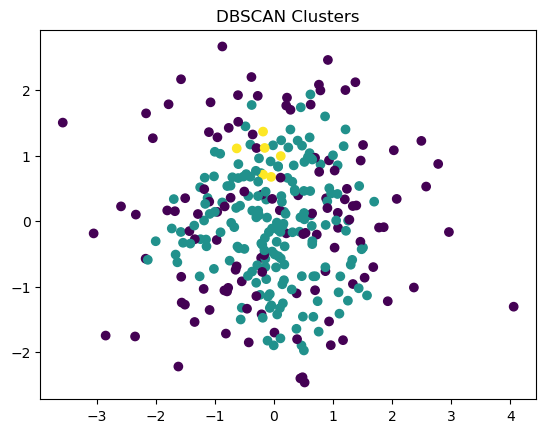

In [5]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

score = silhouette_score(X_scaled, db_labels)
print("DBSCAN Silhouette Score:", round(score,3))

plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap='viridis')
plt.title("DBSCAN Clusters")
plt.show()

## 2. Gaussian Mixture Model (GMM)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


GMM Silhouette Score: 0.098


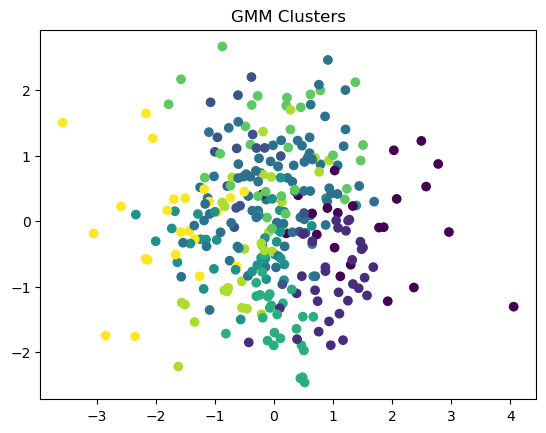

In [6]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

score = silhouette_score(X_scaled, gmm_labels)
print("GMM Silhouette Score:", round(score,3))

plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels, cmap='viridis')
plt.title("GMM Clusters")
plt.show()

## 3. Cluster Validation (Multiple Metrics)

In [7]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

print("Silhouette:", silhouette_score(X_scaled, kmeans_labels))
print("Davies Bouldin:", davies_bouldin_score(X_scaled, kmeans_labels))
print("Calinski Harabasz:", calinski_harabasz_score(X_scaled, kmeans_labels))

Silhouette: 0.19290263418253636
Davies Bouldin: 1.329927096560253
Calinski Harabasz: 55.00904527923505


## 4. Image Segmentation using KMeans

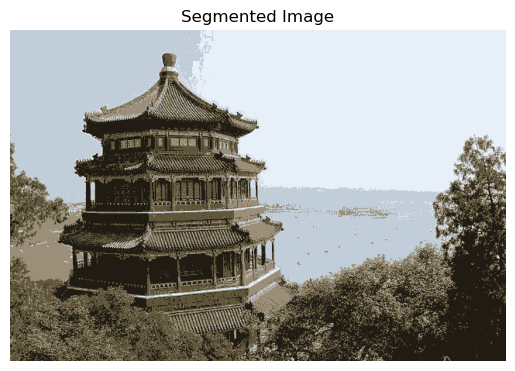

In [8]:
from sklearn.datasets import load_sample_image

china = load_sample_image("china.jpg")
image = np.array(china) / 255.0
w, h, d = image.shape
image_array = image.reshape((w*h, d))

kmeans_img = KMeans(n_clusters=5, random_state=42)
labels = kmeans_img.fit_predict(image_array)

segmented = kmeans_img.cluster_centers_[labels]
segmented = segmented.reshape((w, h, d))

plt.imshow(segmented)
plt.title("Segmented Image")
plt.axis('off')
plt.show()

## 5. Dimensionality Reduction Before Clustering